# Reinforcement Learning for Medicine — Tutorial Notebook

This notebook walks through the core RL concepts covered in the AI for Medicine course,
using **LunarLander** as the running example and ending with a **biomedical application**
— learning dynamic treatment regimes for sepsis management in the ICU.

**Topics covered:**
1. Markov Decision Processes (MDPs) — states, actions, rewards, value functions
2. Vanilla Policy Gradient (REINFORCE)
3. Actor-Critic with Advantage Estimation
4. Proximal Policy Optimization (PPO) with Stable-Baselines3
5. Dynamic Treatment Regimes — RL for Sepsis in the ICU

---
> **LunarLander** — the agent controls thrusters to land a spacecraft safely between two flags.
> Reward: +100 for safe landing, -100 for crash, -0.3 per thruster fire (fuel cost).
> Episode ends when landed, crashed, or 1000 steps elapsed.

In [2]:
# Install required packages (run once; skip if already installed)
# gymnasium: modern OpenAI Gym replacement
# stable-baselines3: high-quality RL implementations
# swig: required for Box2D physics (LunarLander)

import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('gymnasium[box2d]')
install('stable-baselines3[extra]')
install('swig')

In [3]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from collections import deque

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['font.size'] = 11
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

import gymnasium; print('gymnasium:', gymnasium.__version__)
import stable_baselines3; print('stable-baselines3:', stable_baselines3.__version__)

Using device: cuda
gymnasium: 1.2.3


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


stable-baselines3: 2.7.1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Part 1 — Markov Decision Processes (MDPs)

An MDP is the mathematical framework that describes any RL problem.
It has five components:

| Symbol | Name | LunarLander example |
|---|---|---|
| $\mathcal{S}$ | **State space** | 8 continuous values: x, y, velocity, angle, angular velocity, leg contacts |
| $\mathcal{A}$ | **Action space** | 4 discrete: do nothing, fire left, fire main, fire right |
| $P(s'|s,a)$ | **Transition probability** | Physics engine (unknown to the agent) |
| $R(s,a)$ | **Reward function** | +100 land, -100 crash, -0.3 thruster fire |
| $\gamma$ | **Discount factor** | $0 < \gamma < 1$: future rewards worth less than immediate ones |

### 1.1 The Agent-Environment Loop

```
State s_t ──→  Agent (policy π)  ──→  Action a_t
                                          │
                                          ↓
                                    Environment
                                          │
                              ┌───────────┴────────────┐
                           Reward r_t            Next state s_{t+1}
```

The agent's goal is to find a **policy** $\pi(a|s)$ that maximises the **expected discounted return**:

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[R(\tau)\right], \quad R(\tau) = \sum_{t=0}^{T} \gamma^t r_t$$

In [4]:
# ---- Explore the LunarLander environment ----

env = gym.make('LunarLander-v3')

print('=== State (observation) space ===')
print('Shape:', env.observation_space.shape)
print('Low: ', env.observation_space.low.round(2))
print('High:', env.observation_space.high.round(2))
print('\nThe 8 values are:')
for i, name in enumerate(['x position', 'y position', 'x velocity', 'y velocity',
                           'angle', 'angular velocity', 'left leg contact', 'right leg contact']):
    print(f'  s[{i}]: {name}')

print('\n=== Action space ===')
print('n =', env.action_space.n)
for i, a in enumerate(['do nothing', 'fire left engine', 'fire main engine', 'fire right engine']):
    print(f'  a={i}: {a}')

=== State (observation) space ===
Shape: (8,)
Low:  [ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ]
High: [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ]

The 8 values are:
  s[0]: x position
  s[1]: y position
  s[2]: x velocity
  s[3]: y velocity
  s[4]: angle
  s[5]: angular velocity
  s[6]: left leg contact
  s[7]: right leg contact

=== Action space ===
n = 4
  a=0: do nothing
  a=1: fire left engine
  a=2: fire main engine
  a=3: fire right engine


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/

Episode length: 61 steps
Total reward:   -187.2  (a trained agent gets ~200+)


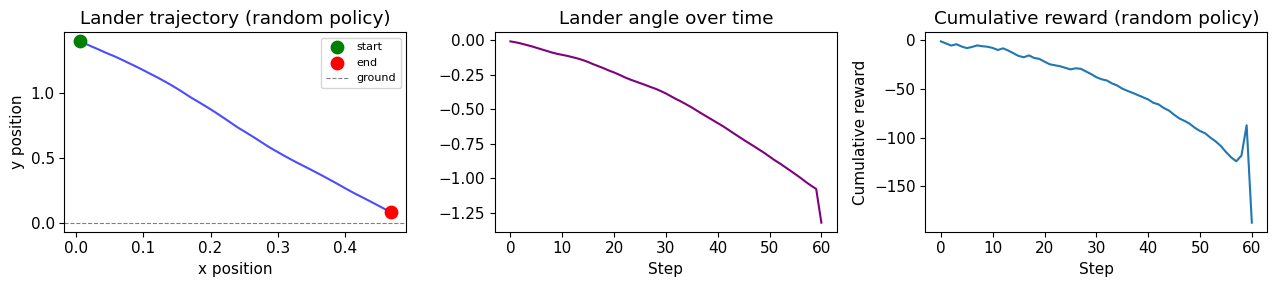

In [5]:
# ---- Run one episode with a RANDOM policy ----

def run_random_episode(env_name='LunarLander-v3', seed=0):
    """Run one episode with random actions. Returns total reward."""
    env = gym.make(env_name)
    state, _ = env.reset(seed=seed)
    total_reward = 0
    states, rewards = [], []

    for step in range(500):
        action = env.action_space.sample()   # random action
        next_state, reward, terminated, truncated, _ = env.step(action)
        states.append(state.copy())
        rewards.append(reward)
        total_reward += reward
        state = next_state
        if terminated or truncated:
            break

    env.close()
    return total_reward, states, rewards

total_reward, states, rewards = run_random_episode()
states = np.array(states)

print(f'Episode length: {len(rewards)} steps')
print(f'Total reward:   {total_reward:.1f}  (a trained agent gets ~200+)')

# Plot trajectory
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(states[:, 0], states[:, 1], 'b-', alpha=0.7)
axes[0].scatter(states[0, 0], states[0, 1], c='green', s=80, zorder=5, label='start')
axes[0].scatter(states[-1, 0], states[-1, 1], c='red', s=80, zorder=5, label='end')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8, label='ground')
axes[0].set_xlabel('x position'); axes[0].set_ylabel('y position')
axes[0].set_title('Lander trajectory (random policy)'); axes[0].legend(fontsize=8)

axes[1].plot(states[:, 4], label='angle', color='purple')
axes[1].set_xlabel('Step'); axes[1].set_title('Lander angle over time')

axes[2].plot(np.cumsum(rewards))
axes[2].set_xlabel('Step'); axes[2].set_ylabel('Cumulative reward')
axes[2].set_title('Cumulative reward (random policy)')

plt.tight_layout(); plt.savefig('random_policy.png', dpi=100); plt.show()

### 1.2 Value Functions

Value functions answer: *"How good is it to be in state $s$ (or to take action $a$ in $s$)?"*

| Function | Formula | Meaning |
|---|---|---|
| $V^\pi(s)$ | $\mathbb{E}_{\tau\sim\pi}[R(\tau)\mid s_0=s]$ | Expected return from $s$ following $\pi$ |
| $Q^\pi(s,a)$ | $\mathbb{E}_{\tau\sim\pi}[R(\tau)\mid s_0=s, a_0=a]$ | Expected return from $s$, taking $a$, then $\pi$ |
| $A^\pi(s,a)$ | $Q^\pi(s,a) - V^\pi(s)$ | **Advantage**: is $a$ better than average? |

### 1.3 Bellman Equations

Value functions satisfy **recursive** (Bellman) equations:

$$V^\pi(s) = \mathbb{E}_{a\sim\pi,\, s'\sim P}\left[r(s,a) + \gamma V^\pi(s')\right]$$

This lets us **bootstrap**: estimate $V^\pi(s_t)$ using the next state's value — no need to wait until the episode ends.

**TD error** (one-step Bellman residual):
$$\delta_t = r_t + \gamma V^\pi(s_{t+1}) - V^\pi(s_t)$$

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

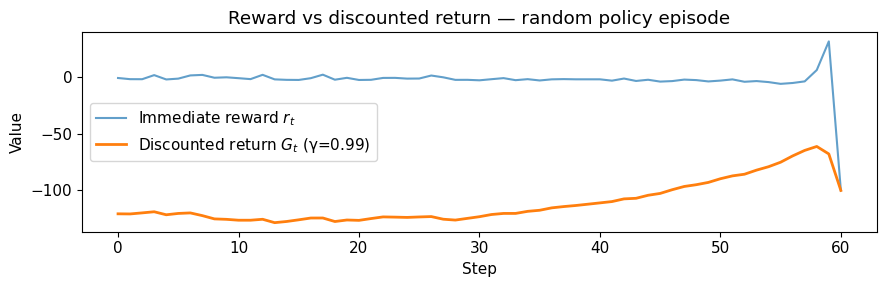

The return G_t at each step = sum of all FUTURE discounted rewards.
Early steps have large G_t because there are many future rewards to accumulate.


In [6]:
# ---- Compute discounted return (Monte Carlo) for one episode ----

def compute_returns(rewards, gamma=0.99):
    """Compute discounted return from each timestep to end of episode."""
    T = len(rewards)
    returns = np.zeros(T)
    G = 0.0
    for t in reversed(range(T)):   # work backwards from the end
        G = rewards[t] + gamma * G
        returns[t] = G
    return returns

returns = compute_returns(rewards, gamma=0.99)

plt.figure(figsize=(9, 3))
plt.plot(rewards,          label='Immediate reward $r_t$',         alpha=0.7)
plt.plot(returns,          label='Discounted return $G_t$ (γ=0.99)',linewidth=2)
plt.xlabel('Step'); plt.ylabel('Value')
plt.title('Reward vs discounted return — random policy episode')
plt.legend(); plt.tight_layout(); plt.show()
print('The return G_t at each step = sum of all FUTURE discounted rewards.')
print('Early steps have large G_t because there are many future rewards to accumulate.')

---
## Part 2 — Vanilla Policy Gradient (REINFORCE)

### How to optimise a policy?

We want to maximise $J(\theta) = \mathbb{E}_{\tau\sim\pi_\theta}[R(\tau)]$ using gradient ascent.
The **log-derivative trick** gives us:

$$\nabla_\theta J(\pi_\theta) = \mathbb{E}_{\tau\sim\pi_\theta}\left[\sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot R(\tau)\right]$$

**Intuition:** if a trajectory had high total reward $R(\tau)$, increase the probability of all actions taken in it.

**Variance reduction** — use **reward-to-go** instead of full $R(\tau)$:
$$\hat{R}_t = \sum_{t'=t}^T \gamma^{t'-t} r_{t'} \quad \text{(only future rewards matter for action at time } t\text{)}$$

### REINFORCE Loss

$$\mathcal{L}(\theta) = -\frac{1}{|\mathcal{D}|}\sum_{\tau\in\mathcal{D}}\sum_{t=0}^T \log\pi_\theta(a_t|s_t)\cdot\hat{R}_t$$

(Negative because PyTorch minimises, but we want to maximise reward.)

In [7]:
# ---- Policy Network ----

class PolicyNetwork(nn.Module):
    """Maps state → probability distribution over actions."""

    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        return Categorical(logits=logits)   # returns a probability distribution


# Quick sanity check
env_demo = gym.make('LunarLander-v3')
state_dim  = env_demo.observation_space.shape[0]   # 8
action_dim = env_demo.action_space.n               # 4

policy = PolicyNetwork(state_dim, action_dim)
s, _ = env_demo.reset()
dist  = policy(torch.tensor(s, dtype=torch.float32))
a     = dist.sample()
lp    = dist.log_prob(a)

print(f'State dim: {state_dim},  Action dim: {action_dim}')
print(f'Sample action: {a.item()},  log_prob: {lp.item():.4f}')
print(f'Action probs:  {dist.probs.detach().numpy().round(3)}')
env_demo.close()

State dim: 8,  Action dim: 4
Sample action: 3,  log_prob: -1.3483
Action probs:  [0.251 0.24  0.25  0.26 ]


In [8]:
# ---- Core REINFORCE functions ----

def collect_episode(env, policy, device):
    """
    Run one episode using the current policy.
    Returns log-probs of actions taken, rewards received.
    """
    state, _ = env.reset()
    log_probs, rewards = [], []

    for _ in range(1000):   # max steps
        state_t = torch.tensor(state, dtype=torch.float32, device=device)
        dist    = policy(state_t)
        action  = dist.sample()

        log_probs.append(dist.log_prob(action))

        state, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(reward)

        if terminated or truncated:
            break

    return log_probs, rewards


def reinforce_loss(log_probs, rewards, gamma=0.99):
    """
    Compute REINFORCE loss using reward-to-go.
    Loss = - sum_t [ log π(a_t|s_t) * G_t ]
    """
    T = len(rewards)

    # Step 1: compute discounted reward-to-go G_t at each timestep
    G = 0.0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32).to(log_probs[0].device)

    # Step 2: normalise returns (reduces variance, stabilises training)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # Step 3: policy gradient loss  L = - 1/T * sum_t [ log π(a_t|s_t) * G_t ]
    log_probs_t = torch.stack(log_probs)
    loss = -(log_probs_t * returns).mean()
    return loss


print('REINFORCE functions defined.')

REINFORCE functions defined.


In [9]:
# ---- Train REINFORCE on LunarLander ----
# Note: vanilla PG has high variance — needs ~1000 episodes for good performance.
# We run 400 episodes here to illustrate the upward trend.
import copy

def train_reinforce(n_episodes=400, lr=3e-4, gamma=0.99, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    env    = gym.make('LunarLander-v3')
    policy = PolicyNetwork(state_dim, action_dim).to(device)
    opt    = optim.Adam(policy.parameters(), lr=lr)

    episode_rewards = []
    running_avg     = deque(maxlen=50)
    avg_rewards     = []
    snapshots       = {}          # {episode: policy_copy}
    snapshot_at     = {50, 200, n_episodes}  # save at these checkpoints

    for ep in range(n_episodes):
        log_probs, rewards = collect_episode(env, policy, device)
        loss = reinforce_loss(log_probs, rewards, gamma)

        opt.zero_grad()
        loss.backward()
        opt.step()

        ep_reward = sum(rewards)
        episode_rewards.append(ep_reward)
        running_avg.append(ep_reward)
        avg_rewards.append(np.mean(running_avg))

        # Save a snapshot of the current policy
        if (ep + 1) in snapshot_at:
            snapshots[ep + 1] = copy.deepcopy(policy)

        if (ep + 1) % 50 == 0:
            print(f'Episode {ep+1:4d}  |  Total reward: {ep_reward:7.1f}  |  '
                  f'50-ep avg: {avg_rewards[-1]:7.1f}')

    env.close()
    return policy, episode_rewards, avg_rewards, snapshots


print('Training REINFORCE on LunarLander (400 episodes)...')
pg_policy, pg_rewards, pg_avg, pg_snapshots = train_reinforce(n_episodes=400)


Training REINFORCE on LunarLander (400 episodes)...
Episode   50  |  Total reward:    33.8  |  50-ep avg:  -183.7


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episode  100  |  Total reward:  -127.7  |  50-ep avg:  -139.7
Episode  150  |  Total reward:   -40.0  |  50-ep avg:  -137.6
Episode  200  |  Total reward:   -98.3  |  50-ep avg:  -142.6
Episode  250  |  Total reward:   -82.7  |  50-ep avg:  -122.4
Episode  300  |  Total reward:  -190.0  |  50-ep avg:  -118.3
Episode  350  |  Total reward:   -68.1  |  50-ep avg:  -130.8
Episode  400  |  Total reward:   -41.4  |  50-ep avg:  -131.8


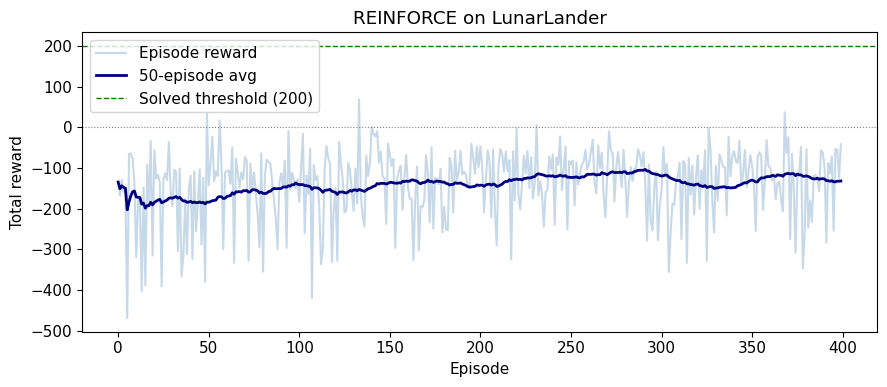

In [10]:
def plot_training(rewards, avg_rewards, title):
    plt.figure(figsize=(9, 4))
    plt.plot(rewards,     alpha=0.3, color='steelblue', label='Episode reward')
    plt.plot(avg_rewards, color='navy', linewidth=2,    label='50-episode avg')
    plt.axhline(200, color='green', linestyle='--', linewidth=1, label='Solved threshold (200)')
    plt.axhline(0,   color='gray',  linestyle=':',  linewidth=0.8)
    plt.xlabel('Episode'); plt.ylabel('Total reward')
    plt.title(title); plt.legend(); plt.tight_layout()
    plt.savefig(title.replace(' ', '_') + '.png', dpi=100); plt.show()

plot_training(pg_rewards, pg_avg, 'REINFORCE on LunarLander')

---
## Part 3 — Actor-Critic with Advantage Estimation

### Problem with REINFORCE

The reward-to-go $\hat{R}_t$ can be very noisy (high variance) because it depends on the full stochastic trajectory.

### Solution: Subtract a Baseline (Critic)

Subtracting any baseline $b(s_t)$ that doesn't depend on the action leaves the gradient **unbiased** but **reduces variance**.
The best baseline is the **value function** $V^\pi(s_t)$, giving the **advantage**:

$$A_t = \hat{R}_t - V^\pi(s_t)$$

This answers: *"Was this action better or worse than the average for this state?"*

### Actor-Critic Algorithm

- **Actor** (policy $\pi_\theta$): chooses actions, updated using advantage
- **Critic** (value function $V_\phi$): estimates $V^\pi(s)$, updated to minimise $\sum_t (V_\phi(s_t) - \hat{R}_t)^2$

**TD advantage** (one-step, lower variance than Monte Carlo):
$$A_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$$

In [11]:
# ---- Actor-Critic Network ----
# One shared trunk, two heads: policy (actor) + value function (critic)

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        # Shared feature extractor
        self.trunk = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
        )
        # Actor head: outputs action logits
        self.actor  = nn.Linear(hidden, action_dim)
        # Critic head: outputs scalar state value
        self.critic = nn.Linear(hidden, 1)

    def forward(self, x):
        features = self.trunk(x)
        dist  = Categorical(logits=self.actor(features))   # action distribution
        value = self.critic(features).squeeze(-1)          # V(s)
        return dist, value


# Sanity check
ac = ActorCritic(state_dim, action_dim)
s_demo = torch.zeros(state_dim)
dist, val = ac(s_demo)
print(f'Action probs: {dist.probs.detach().numpy().round(3)}')
print(f'Value V(s):   {val.item():.4f}')

Action probs: [0.218 0.264 0.246 0.272]
Value V(s):   -0.0107


In [12]:
# ---- Actor-Critic Training Loop ----

def train_actor_critic(n_episodes=500, lr=3e-4, gamma=0.99,
                        actor_coef=1.0, critic_coef=0.5,
                        entropy_coef=0.01, seed=42):
    """
    actor_coef:   weight on policy gradient loss
    critic_coef:  weight on value function loss
    entropy_coef: weight on entropy bonus (encourages exploration)
    """
    torch.manual_seed(seed); np.random.seed(seed)
    env    = gym.make('LunarLander-v3')
    model  = ActorCritic(state_dim, action_dim).to(device)
    opt    = optim.Adam(model.parameters(), lr=lr)

    episode_rewards = []
    running_avg     = deque(maxlen=50)
    avg_rewards     = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        ep_reward = 0

        log_probs, values, rewards, entropies = [], [], [], []

        for _ in range(1000):
            state_t = torch.tensor(state, dtype=torch.float32, device=device)
            dist, value = model(state_t)

            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            values.append(value)
            entropies.append(dist.entropy())          # H(π) encourages exploration

            state, reward, terminated, truncated, _ = env.step(action.item())
            rewards.append(reward)
            ep_reward += reward

            if terminated or truncated:
                break

        # ---- Compute returns and advantages ----
        G = 0.0
        returns_list = []
        for r in reversed(rewards):
            G = r + gamma * G
            returns_list.insert(0, G)
        returns_t = torch.tensor(returns_list, dtype=torch.float32, device=device)
        returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        values_t   = torch.stack(values)
        log_probs_t= torch.stack(log_probs)
        entropy_t  = torch.stack(entropies).mean()

        # Advantage = G_t - V(s_t)  (how much better was this trajectory than expected?)
        advantages = returns_t - values_t.detach()

        # ---- Losses ----
        actor_loss  = -(log_probs_t * advantages).mean()          # policy gradient
        critic_loss = nn.functional.mse_loss(values_t, returns_t) # value function
        entropy_loss= -entropy_t                                   # negative entropy (to maximise)

        loss = actor_coef * actor_loss + critic_coef * critic_loss + entropy_coef * entropy_loss

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)  # gradient clipping
        opt.step()

        episode_rewards.append(ep_reward)
        running_avg.append(ep_reward)
        avg_rewards.append(np.mean(running_avg))

        if (ep + 1) % 50 == 0:
            print(f'Episode {ep+1:4d}  |  Total reward: {ep_reward:7.1f}  |  '
                  f'50-ep avg: {avg_rewards[-1]:7.1f}')

    env.close()
    return model, episode_rewards, avg_rewards


print('Training Actor-Critic on LunarLander (500 episodes)...')
ac_model, ac_rewards, ac_avg = train_actor_critic(n_episodes=500)

Training Actor-Critic on LunarLander (500 episodes)...
Episode   50  |  Total reward:  -378.1  |  50-ep avg:  -201.9
Episode  100  |  Total reward:  -124.9  |  50-ep avg:  -170.3
Episode  150  |  Total reward:  -306.5  |  50-ep avg:  -154.7
Episode  200  |  Total reward:  -100.6  |  50-ep avg:  -160.3
Episode  250  |  Total reward:  -111.7  |  50-ep avg:  -150.2
Episode  300  |  Total reward:  -169.0  |  50-ep avg:  -131.8
Episode  350  |  Total reward:   -35.1  |  50-ep avg:  -130.1
Episode  400  |  Total reward:  -108.2  |  50-ep avg:  -172.5
Episode  450  |  Total reward:   -19.0  |  50-ep avg:  -140.0
Episode  500  |  Total reward:   -87.7  |  50-ep avg:  -140.7


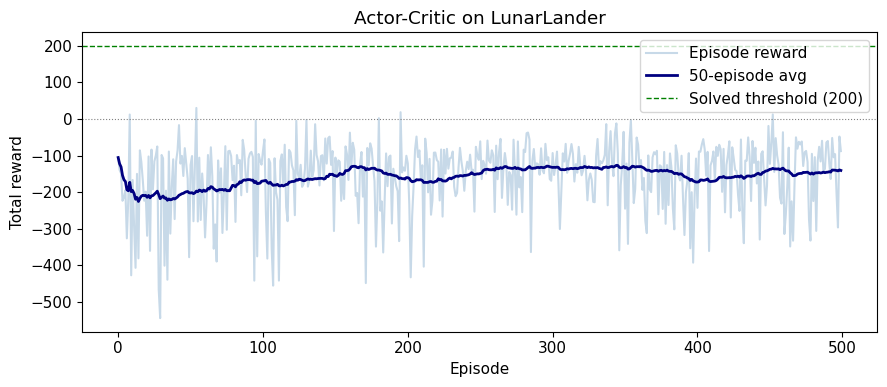

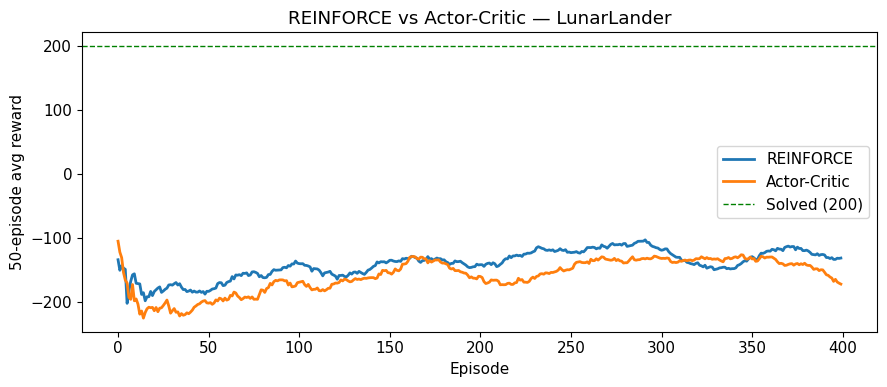

In [13]:
plot_training(ac_rewards, ac_avg, 'Actor-Critic on LunarLander')

# Compare REINFORCE vs Actor-Critic learning curves
min_ep = min(len(pg_avg), len(ac_avg))
plt.figure(figsize=(9, 4))
plt.plot(pg_avg[:min_ep], label='REINFORCE',     linewidth=2)
plt.plot(ac_avg[:min_ep], label='Actor-Critic',  linewidth=2)
plt.axhline(200, color='green', linestyle='--', linewidth=1, label='Solved (200)')
plt.xlabel('Episode'); plt.ylabel('50-episode avg reward')
plt.title('REINFORCE vs Actor-Critic — LunarLander')
plt.legend(); plt.tight_layout()
plt.savefig('pg_vs_ac.png', dpi=100); plt.show()

---
## Part 4 — Proximal Policy Optimization (PPO)

### Why vanilla PG is unstable

A large gradient step in **parameter space** $\theta$ can cause a catastrophically large change in **policy** $\pi_\theta$.
If the policy changes too much, the collected experience is no longer representative, and training diverges.

### PPO's key idea — clip the policy ratio

PPO reuses data from the **old policy** $\pi_{\theta_k}$ via **importance sampling**, then clips the policy ratio to prevent large updates:

$$r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_k}(a_t|s_t)}$$

$$\mathcal{L}^{\text{PPO}}(\theta) = \mathbb{E}_t\left[\min\left(r_t(\theta)\, A_t,\; \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)\, A_t\right)\right]$$

The clip prevents the ratio from going above $1+\varepsilon$ (for positive advantage) or below $1-\varepsilon$ (for negative advantage). Typical $\varepsilon = 0.2$.

**Intuition:**
- Positive $A_t$: action was good → increase its probability, but not by more than factor $(1+\varepsilon)$
- Negative $A_t$: action was bad → decrease its probability, but not by more than factor $(1-\varepsilon)$

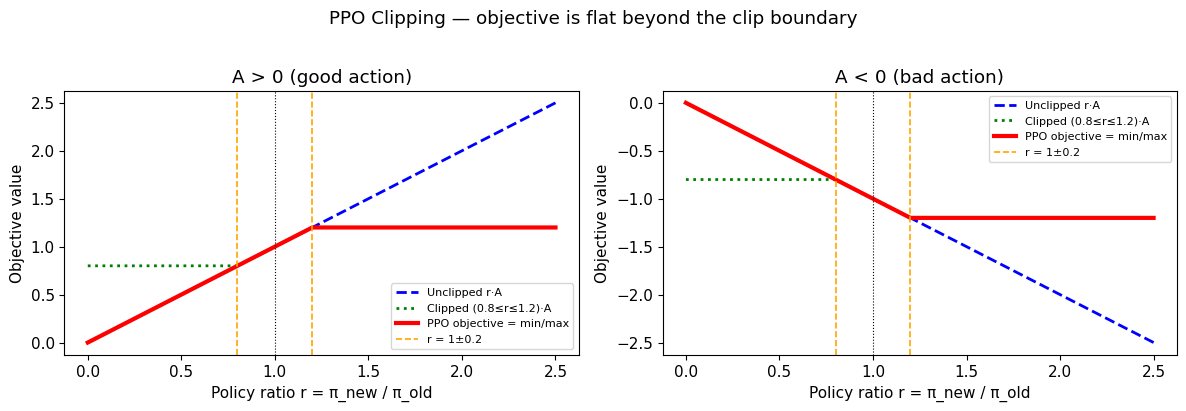

Once ratio is outside [1-ε, 1+ε], there is no gradient incentive to push further.


In [14]:
# ---- Visualise the PPO clipping mechanism ----

r = np.linspace(0.0, 2.5, 300)   # policy ratio π_new / π_old
eps = 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, A, label in zip(axes, [1.0, -1.0], ['A > 0 (good action)', 'A < 0 (bad action)']):
    unclipped = r * A
    clipped   = np.clip(r, 1 - eps, 1 + eps) * A
    ppo_loss  = np.minimum(unclipped, clipped) if A > 0 else np.maximum(unclipped, clipped)

    ax.plot(r, unclipped, 'b--', linewidth=2, label='Unclipped r·A')
    ax.plot(r, clipped,   'g:',  linewidth=2, label=f'Clipped ({1-eps}≤r≤{1+eps})·A')
    ax.plot(r, ppo_loss,  'r',   linewidth=3, label='PPO objective = min/max')
    ax.axvline(1,     color='k', linewidth=0.8, linestyle=':')
    ax.axvline(1+eps, color='orange', linewidth=1.2, linestyle='--', label=f'r = 1±{eps}')
    ax.axvline(1-eps, color='orange', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Policy ratio r = π_new / π_old')
    ax.set_ylabel('Objective value')
    ax.set_title(label); ax.legend(fontsize=8)

plt.suptitle('PPO Clipping — objective is flat beyond the clip boundary', y=1.02)
plt.tight_layout()
plt.savefig('ppo_clip.png', dpi=100); plt.show()
print('Once ratio is outside [1-ε, 1+ε], there is no gradient incentive to push further.')

In [15]:
# ---- PPO Implementation ----

class PPOAgent:
    """Minimal PPO with clipped surrogate objective."""

    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99,
                 eps_clip=0.2, n_epochs=4, hidden=128):
        self.gamma    = gamma
        self.eps_clip = eps_clip
        self.n_epochs = n_epochs

        self.model = ActorCritic(state_dim, action_dim, hidden).to(device)
        self.opt   = optim.Adam(self.model.parameters(), lr=lr)

    def select_action(self, state):
        state_t = torch.tensor(state, dtype=torch.float32, device=device)
        with torch.no_grad():
            dist, value = self.model(state_t)
        action = dist.sample()
        return action.item(), dist.log_prob(action).item(), value.item()

    def update(self, states, actions, old_log_probs, returns, advantages):
        """
        Update using multiple epochs over the collected batch
        (the key efficiency gain of PPO over vanilla PG).
        """
        states_t      = torch.tensor(states,        dtype=torch.float32, device=device)
        actions_t     = torch.tensor(actions,        dtype=torch.long,    device=device)
        old_lp_t      = torch.tensor(old_log_probs, dtype=torch.float32, device=device)
        returns_t     = torch.tensor(returns,        dtype=torch.float32, device=device)
        advantages_t  = torch.tensor(advantages,     dtype=torch.float32, device=device)
        # Normalise advantages
        advantages_t  = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        for _ in range(self.n_epochs):   # reuse data n_epochs times
            dist, values = self.model(states_t)
            new_log_probs = dist.log_prob(actions_t)
            entropy       = dist.entropy().mean()

            # Policy ratio
            ratio = torch.exp(new_log_probs - old_lp_t)

            # Clipped PPO surrogate loss
            surr1 = ratio * advantages_t
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantages_t
            actor_loss  = -torch.min(surr1, surr2).mean()
            critic_loss = nn.functional.mse_loss(values, returns_t)

            loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

            self.opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
            self.opt.step()


print('PPOAgent class defined.')

PPOAgent class defined.


In [16]:
def train_ppo(n_episodes=600, update_every=20, seed=42):
    """
    update_every: collect this many episodes, then do one PPO update.
    Batching data is more efficient than updating after every single episode.
    """
    torch.manual_seed(seed); np.random.seed(seed)
    env   = gym.make('LunarLander-v3')
    agent = PPOAgent(state_dim, action_dim)

    episode_rewards = []
    running_avg     = deque(maxlen=50)
    avg_rewards     = []
    snapshots       = {}                        # {episode: model_copy}
    snapshot_at     = {100, 300, n_episodes}    # save at these checkpoints

    # Buffers for the current batch
    buf_states, buf_actions, buf_log_probs, buf_returns, buf_advantages = [], [], [], [], []

    for ep in range(n_episodes):
        state, _ = env.reset()
        ep_states, ep_actions, ep_log_probs, ep_rewards, ep_values = [], [], [], [], []
        ep_reward = 0

        for _ in range(1000):
            action, log_prob, value = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            ep_states.append(state.copy())
            ep_actions.append(action)
            ep_log_probs.append(log_prob)
            ep_rewards.append(reward)
            ep_values.append(value)
            ep_reward += reward
            state = next_state

            if terminated or truncated:
                break

        # Compute returns and advantages for this episode
        G = 0.0
        ep_returns = []
        for r in reversed(ep_rewards):
            G = r + 0.99 * G
            ep_returns.insert(0, G)
        ep_advantages = [G - v for G, v in zip(ep_returns, ep_values)]

        buf_states.extend(ep_states)
        buf_actions.extend(ep_actions)
        buf_log_probs.extend(ep_log_probs)
        buf_returns.extend(ep_returns)
        buf_advantages.extend(ep_advantages)

        episode_rewards.append(ep_reward)
        running_avg.append(ep_reward)
        avg_rewards.append(np.mean(running_avg))

        # PPO update every `update_every` episodes
        if (ep + 1) % update_every == 0:
            agent.update(np.array(buf_states), np.array(buf_actions),
                         np.array(buf_log_probs), np.array(buf_returns),
                         np.array(buf_advantages))
            buf_states, buf_actions, buf_log_probs, buf_returns, buf_advantages = [], [], [], [], []

        # Save a snapshot of the current policy
        if (ep + 1) in snapshot_at:
            import copy
            snapshots[ep + 1] = copy.deepcopy(agent.model)

        if (ep + 1) % 100 == 0:
            print(f'Episode {ep+1:4d}  |  Total: {ep_reward:7.1f}  |  50-avg: {avg_rewards[-1]:7.1f}')

    env.close()
    return agent, episode_rewards, avg_rewards, snapshots


print('Training PPO on LunarLander (600 episodes)...')
ppo_agent, ppo_rewards, ppo_avg, ppo_snapshots = train_ppo(n_episodes=600)


Training PPO on LunarLander (600 episodes)...
Episode  100  |  Total:  -249.9  |  50-avg:  -194.4
Episode  200  |  Total:   -16.5  |  50-avg:  -167.6
Episode  300  |  Total:  -300.4  |  50-avg:  -162.1
Episode  400  |  Total:  -329.4  |  50-avg:  -147.9
Episode  500  |  Total:  -168.9  |  50-avg:  -152.7
Episode  600  |  Total:  -183.4  |  50-avg:  -156.4


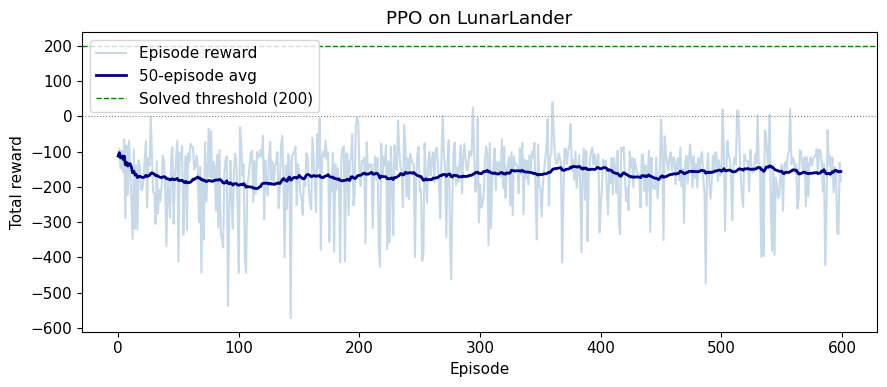

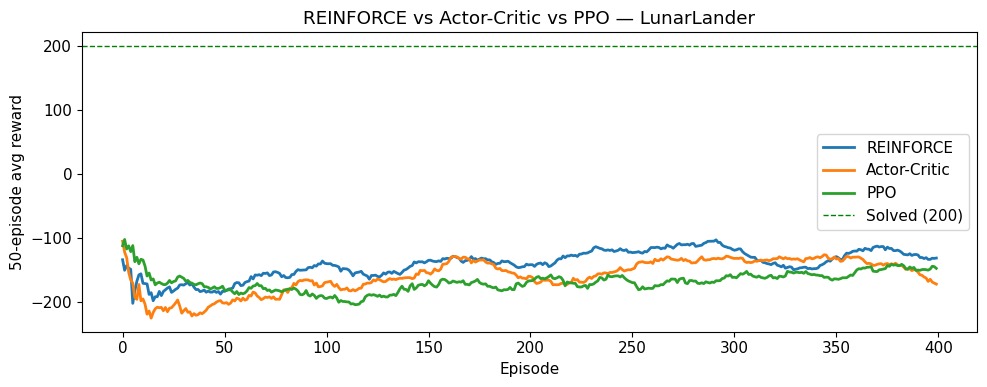

In [17]:
plot_training(ppo_rewards, ppo_avg, 'PPO on LunarLander')

# Final comparison of all three methods
min_ep = min(len(pg_avg), len(ac_avg), len(ppo_avg))
plt.figure(figsize=(10, 4))
plt.plot(pg_avg[:min_ep],  label='REINFORCE',    linewidth=2)
plt.plot(ac_avg[:min_ep],  label='Actor-Critic', linewidth=2)
plt.plot(ppo_avg[:min_ep], label='PPO',          linewidth=2)
plt.axhline(200, color='green', linestyle='--', linewidth=1, label='Solved (200)')
plt.xlabel('Episode'); plt.ylabel('50-episode avg reward')
plt.title('REINFORCE vs Actor-Critic vs PPO — LunarLander')
plt.legend(); plt.tight_layout()
plt.savefig('all_methods.png', dpi=100); plt.show()

Random baseline: 61 frames
REINFORCE ep 50: 118 frames
REINFORCE ep 200: 118 frames
REINFORCE ep 400: 118 frames
PPO ep 100: 78 frames
PPO ep 300: 82 frames
PPO ep 600: 81 frames


Method,Early,Mid,Trained
Random baseline,,not available,not available
REINFORCE,,,
PPO (custom),,,

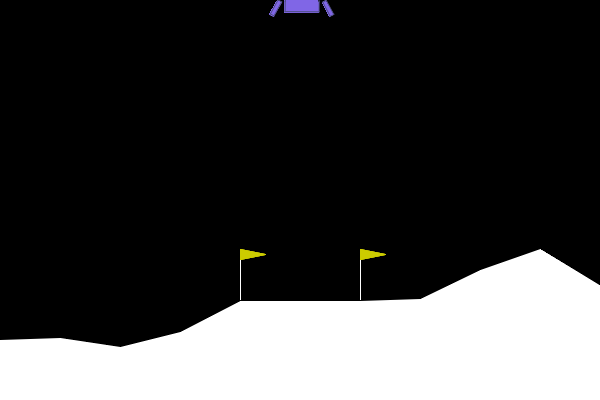
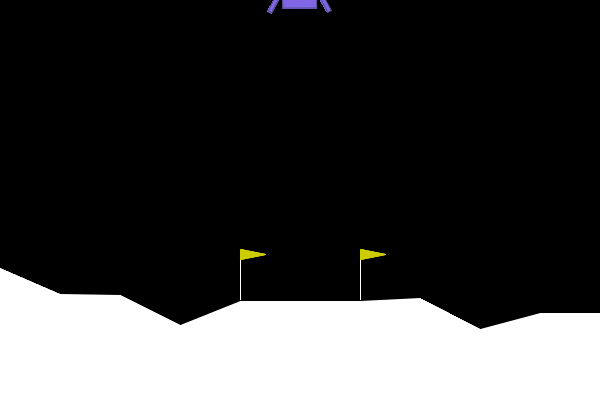
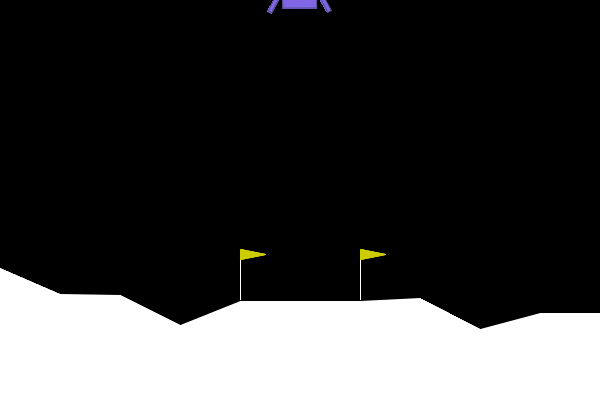
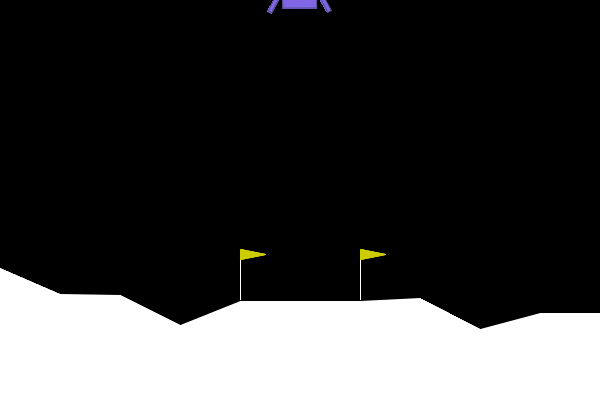
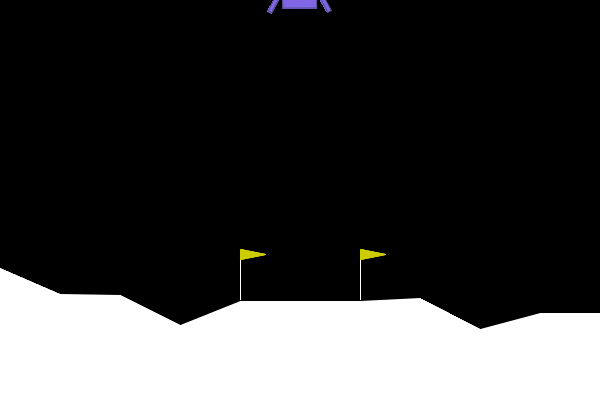
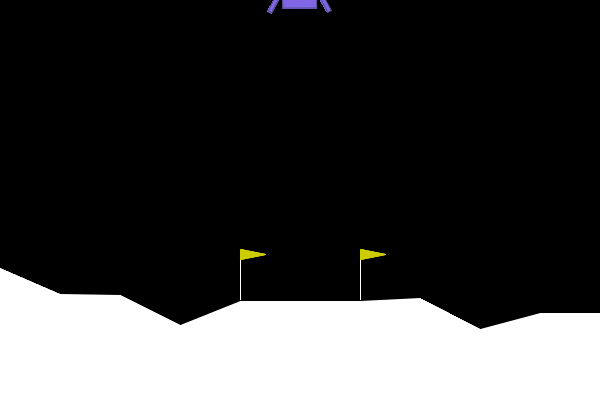
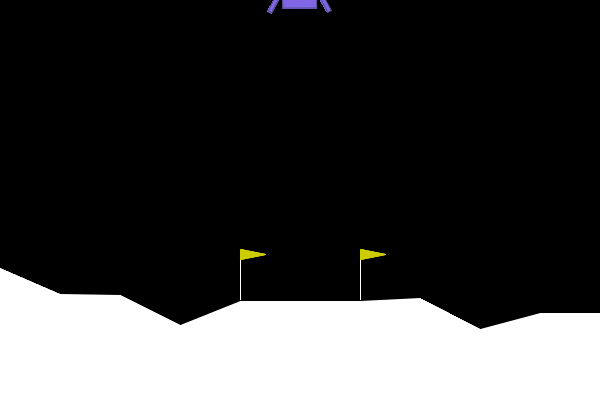

In [18]:
# ---- Visualise training progress as GIFs ----
# Each column = a stage of training (early / mid / fully trained).
# Rows: random baseline / REINFORCE / PPO.
# Requires: pg_snapshots (from train_reinforce) and ppo_snapshots (from train_ppo).

import imageio.v2 as imageio
from IPython.display import display, HTML
import os, base64

# ── helper: record one greedy episode as a list of RGB frames ────────────────
def record_frames(model, env_name='LunarLander-v3', seed=0,
                  max_steps=600, is_actor_critic=False):
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset(seed=seed)
    frames = []
    for _ in range(max_steps):
        frames.append(env.render())
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=device)
            dist, _ = model(s) if is_actor_critic else (model(s), None)
            action = dist.probs.argmax().item()   # greedy
        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break
    env.close()
    return frames


def frames_to_gif(frames, path, fps=30):
    """Save frames as GIF.  imageio v2 uses duration (ms), not fps."""
    duration_ms = int(1000 / fps)
    imageio.mimsave(path, [f.astype('uint8') for f in frames],
                    duration=duration_ms, loop=0)


def gif_html(path, width=260):
    """Return an <img> tag with the GIF embedded as base64."""
    with open(path, 'rb') as f:
        data = base64.b64encode(f.read()).decode()
    return f'<img src="data:image/gif;base64,{data}" style="width:{width}px"/>'


os.makedirs('gifs', exist_ok=True)

# ── Random baseline ──────────────────────────────────────────────────────────
env_r = gym.make('LunarLander-v3', render_mode='rgb_array')
s, _  = env_r.reset(seed=0)
f_rand = []
for _ in range(400):
    f_rand.append(env_r.render())
    s, _, done, trunc, _ = env_r.step(env_r.action_space.sample())
    if done or trunc: break
env_r.close()
frames_to_gif(f_rand, 'gifs/random.gif')
print(f'Random baseline: {len(f_rand)} frames')

# ── REINFORCE snapshots (need pg_snapshots from train_reinforce) ─────────────
if 'pg_snapshots' not in dir() and 'pg_snapshots' not in locals():
    print('WARNING: pg_snapshots not found — re-run the REINFORCE training cell first.')
else:
    pg_keys = sorted(pg_snapshots.keys())   # e.g. [50, 200, 400]
    for k in pg_keys:
        frames = record_frames(pg_snapshots[k], is_actor_critic=False, seed=1)
        frames_to_gif(frames, f'gifs/reinforce_ep{k}.gif')
        print(f'REINFORCE ep {k}: {len(frames)} frames')

# ── PPO snapshots (need ppo_snapshots from train_ppo) ────────────────────────
if 'ppo_snapshots' not in dir() and 'ppo_snapshots' not in locals():
    print('WARNING: ppo_snapshots not found — re-run the PPO training cell first.')
else:
    ppo_keys = sorted(ppo_snapshots.keys())   # e.g. [100, 300, 600]
    for k in ppo_keys:
        frames = record_frames(ppo_snapshots[k], is_actor_critic=True, seed=1)
        frames_to_gif(frames, f'gifs/ppo_ep{k}.gif')
        print(f'PPO ep {k}: {len(frames)} frames')

# ── Build HTML comparison table ──────────────────────────────────────────────
def cell_html(gif_path):
    return gif_html(gif_path) if gif_path and os.path.exists(gif_path)            else '<span style="color:gray">not available</span>'

pg_keys  = sorted(pg_snapshots.keys())  if 'pg_snapshots'  in dir() else []
ppo_keys = sorted(ppo_snapshots.keys()) if 'ppo_snapshots' in dir() else []

html  = '<h3>LunarLander — agent behaviour at different training stages</h3>'
html += '<table style="border-collapse:collapse;text-align:center;font-family:sans-serif">'
html += '<tr style="background:#f0f0f0">'
html += '<th style="padding:8px 12px">Method</th>'
html += '<th style="padding:8px 12px">Early</th>'
html += '<th style="padding:8px 12px">Mid</th>'
html += '<th style="padding:8px 12px">Trained</th></tr>'

rows = [
    ('Random baseline',
     'gifs/random.gif', None, None),
    ('REINFORCE',
     *[f'gifs/reinforce_ep{k}.gif' if pg_keys else None for k in (pg_keys + [None,None,None])[:3]]),
    ('PPO (custom)',
     *[f'gifs/ppo_ep{k}.gif' if ppo_keys else None for k in (ppo_keys + [None,None,None])[:3]]),
]

for label, early, mid, trained in rows:
    html += f'<tr><td style="padding:8px;font-weight:bold">{label}</td>'
    for p in [early, mid, trained]:
        html += f'<td style="padding:6px">{cell_html(p)}</td>'
    html += '</tr>'

html += '</table>'
html += '<p><i>Each panel = one greedy episode. Watch the agent improve left → right.</i></p>'
display(HTML(html))


### 4.1 PPO with Stable-Baselines3 (production-grade)

In practice, use the well-tested [Stable-Baselines3](https://github.com/DLR-RM/stable-baselines3) implementation.
It handles parallelised environments, proper GAE, and hyperparameter tuning for you.

In [19]:
from stable_baselines3 import PPO as SB3_PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
import os

# Create 4 parallel environments for faster experience collection
vec_env  = make_vec_env('LunarLander-v3', n_envs=4, seed=42)
eval_env = make_vec_env('LunarLander-v3', n_envs=2, seed=0)

# Save best model during training
os.makedirs('./logs', exist_ok=True)
eval_cb = EvalCallback(eval_env, best_model_save_path='./logs/',
                       eval_freq=5000, n_eval_episodes=10, verbose=0)

# Hyperparameters tuned for LunarLander (from RL Baselines3 Zoo)
sb3_model = SB3_PPO(
    'MlpPolicy', vec_env,
    n_steps     = 1024,    # steps per env before update
    batch_size  = 64,
    gae_lambda  = 0.98,    # GAE smoothing parameter
    gamma       = 0.999,
    n_epochs    = 4,
    ent_coef    = 0.01,    # entropy bonus coefficient
    verbose     = 1,
)

print('Training SB3 PPO (500,000 timesteps ≈ ~5 min on CPU)...')
sb3_model.learn(total_timesteps=500_000, callback=eval_cb)
print('Done!')

Using cuda device
Training SB3 PPO (500,000 timesteps ≈ ~5 min on CPU)...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 90.9     |
|    ep_rew_mean     | -196     |
| time/              |          |
|    fps             | 2058     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 4096     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 90.9        |
|    ep_rew_mean          | -173        |
| time/                   |             |
|    fps                  | 1607        |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.004360625 |
|    clip_fraction        | 0.0036      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.000107    |
|    learning_rate        | 0.

In [20]:
# Evaluate the trained SB3 model
best_model = SB3_PPO.load('./logs/best_model.zip', env=eval_env)
mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20)
print(f'SB3 PPO  —  mean reward: {mean_reward:.1f} ± {std_reward:.1f}  (over 20 episodes)')
print('A score > 200 is considered "solved".')

SB3 PPO  —  mean reward: 68.7 ± 83.2  (over 20 episodes)
A score > 200 is considered "solved".


---
## Part 5 — Dynamic Treatment Regimes: RL for Sepsis in the ICU

### Clinical Background

**Sepsis** is a life-threatening organ dysfunction caused by a dysregulated response to infection.
It kills ~270,000 Americans per year and requires rapid, adaptive treatment decisions.

Treatment involves two main interventions with continuous dose adjustments:
- **Vasopressors** (e.g., norepinephrine) — raise blood pressure
- **IV fluids** — restore circulating volume

Getting the balance right is difficult: too little fluid → shock; too much → pulmonary oedema.

### RL Framing (Komorowski et al., *Nature Medicine* 2018)

| RL component | Clinical meaning |
|---|---|
| **State** $s_t$ | Patient vitals at hour $t$: HR, MAP, lactate, SOFA score |
| **Action** $a_t$ | Combined vasopressor + fluid dose (discretised into 5 levels) |
| **Reward** $r_t$ | Negative SOFA change (improvement); +/- 15 at 90-day survival/death |
| **Policy** $\pi$ | Treatment decision function — what to give based on patient state |
| **Goal** | Maximise expected 90-day survival |

We build a **simplified simulation** to demonstrate the concept.

In [21]:
# ---- Sepsis Treatment Simulator ----
# A simplified patient model for illustration.
# State: [heart_rate, MAP, lactate, SOFA_score] — all normalised to [-1, 1]
# Actions: 0=conservative  1=moderate  2=aggressive
# Episode = up to 24 hourly decision points (24 hours of ICU care)

import gymnasium as gym
from gymnasium import spaces

class SepsisEnv(gym.Env):
    """
    Simplified ICU sepsis management environment.

    Clinical state dimensions (normalised to [-1, 1]):
      s[0]: heart rate      (60–180 bpm)  — higher is worse
      s[1]: MAP             (40–120 mmHg) — lower is worse
      s[2]: lactate         (0.5–15 mmol) — higher is worse
      s[3]: SOFA score      (0–24)        — higher is worse

    Actions:
      0 = conservative  (low vasopressor + low fluids)
      1 = standard      (moderate vasopressor + moderate fluids)
      2 = aggressive    (high vasopressor + high fluids)

    Reward: improvement in SOFA score, +15 survival bonus, -15 death penalty.
    """

    # Physiologically normal ranges (used for normalisation)
    HR_MIN, HR_MAX       = 60,  180
    MAP_MIN, MAP_MAX     = 40,  120
    LAC_MIN, LAC_MAX     = 0.5, 15.0
    SOFA_MIN, SOFA_MAX   = 0,   24

    def __init__(self, max_steps=24):
        super().__init__()
        self.max_steps = max_steps
        self.observation_space = spaces.Box(-1.0, 1.0, shape=(4,), dtype=np.float32)
        self.action_space      = spaces.Discrete(3)

    # ---- helpers ----
    def _normalise(self, val, lo, hi):
        return np.clip(2 * (val - lo) / (hi - lo) - 1, -1, 1)

    def _denormalise(self, val, lo, hi):
        return lo + (val + 1) / 2 * (hi - lo)

    def _get_obs(self):
        return np.array([
            self._normalise(self.hr,   self.HR_MIN,   self.HR_MAX),
            self._normalise(self.map_,  self.MAP_MIN,  self.MAP_MAX),
            self._normalise(self.lac,  self.LAC_MIN,  self.LAC_MAX),
            self._normalise(self.sofa, self.SOFA_MIN, self.SOFA_MAX),
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Initialise patient in severe sepsis
        self.hr   = float(self.np_random.uniform(110, 150))   # tachycardia
        self.map_ = float(self.np_random.uniform(50,  70))    # hypotension
        self.lac  = float(self.np_random.uniform(3.0, 8.0))   # elevated lactate
        self.sofa = float(self.np_random.uniform(8,   15))    # high SOFA (severe)
        self.step_count = 0
        return self._get_obs(), {}

    def step(self, action):
        prev_sofa = self.sofa

        # Treatment effects (simplified physiology)
        # Conservative: mild improvement, low risk
        # Standard: moderate improvement
        # Aggressive: strong improvement but side-effect noise
        effect = [0.3, 0.7, 1.2][action]
        noise  = self.np_random.normal(0, [0.2, 0.3, 0.6][action])

        # Update vitals
        self.hr   = np.clip(self.hr   - effect * 5  + noise * 8,  60, 180)
        self.map_ = np.clip(self.map_ + effect * 4  + noise * 5,  40, 120)
        self.lac  = np.clip(self.lac  - effect * 0.6 + noise * 0.4, 0.5, 15)

        # SOFA improves with treatment but has stochastic component
        sofa_delta = -effect * 0.5 + abs(noise) * 0.2
        self.sofa  = np.clip(self.sofa + sofa_delta, 0, 24)

        # Reward: SOFA improvement is good; aggressive treatment has side-effect cost
        reward = (prev_sofa - self.sofa) * 2   # positive if SOFA decreased
        reward -= [0.0, 0.1, 0.3][action]      # treatment burden

        self.step_count += 1

        # Terminal conditions
        recovered = (self.sofa < 2 and self.map_ > 70 and self.hr < 100 and self.lac < 2)
        died      = (self.sofa > 18 or self.map_ < 45)
        truncated = self.step_count >= self.max_steps

        if recovered:
            reward += 15.0; terminated = True
        elif died:
            reward -= 15.0; terminated = True
        else:
            terminated = False

        info = {'hr': self.hr, 'map': self.map_, 'lactate': self.lac, 'sofa': self.sofa,
                'recovered': recovered, 'died': died}
        return self._get_obs(), float(reward), terminated, truncated, info


# Verify the environment
env_check = SepsisEnv()
obs, _ = env_check.reset(seed=0)
print('Initial patient state (normalised):', obs.round(3))
print(f'Initial HR: {env_check.hr:.1f}  MAP: {env_check.map_:.1f}  '
      f'Lactate: {env_check.lac:.2f}  SOFA: {env_check.sofa:.1f}')

Initial patient state (normalised): [ 0.258 -0.615 -0.627 -0.324]
Initial HR: 135.5  MAP: 55.4  Lactate: 3.20  SOFA: 8.1


In [22]:
# ---- Compare random policy vs trained PPO on the sepsis environment ----

def evaluate_sepsis_policy(policy_fn, n_episodes=200, seed=0):
    """Run multiple sepsis episodes and track outcomes."""
    env = SepsisEnv()
    outcomes = {'recovered': 0, 'died': 0, 'truncated': 0, 'rewards': []}

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_r = 0
        for _ in range(24):
            action = policy_fn(obs)
            obs, r, terminated, truncated, info = env.step(action)
            total_r += r
            if terminated or truncated:
                if info.get('recovered'):  outcomes['recovered'] += 1
                elif info.get('died'):     outcomes['died']      += 1
                else:                      outcomes['truncated'] += 1
                break
        outcomes['rewards'].append(total_r)

    outcomes['recovery_rate']  = outcomes['recovered'] / n_episodes
    outcomes['mortality_rate'] = outcomes['died']      / n_episodes
    outcomes['mean_reward']    = np.mean(outcomes['rewards'])
    return outcomes


# Random policy
env_tmp = SepsisEnv()
random_policy = lambda obs: env_tmp.action_space.sample()
rand_outcomes = evaluate_sepsis_policy(random_policy)

# "Always standard" heuristic policy
standard_policy = lambda obs: 1
std_outcomes    = evaluate_sepsis_policy(standard_policy)

# State-aware heuristic: look at SOFA normalised score
def clinical_heuristic(obs):
    """Simple rule: escalate treatment if SOFA or lactate is high."""
    sofa_norm, lac_norm = obs[3], obs[2]
    if sofa_norm > 0.3 or lac_norm > 0.3:   # severe
        return 2  # aggressive
    elif sofa_norm > -0.3 or lac_norm > -0.3:
        return 1  # standard
    else:
        return 0  # conservative (patient improving)

heur_outcomes = evaluate_sepsis_policy(clinical_heuristic)

print('Policy Comparison (200 simulated patients):')
print(f'{"Policy":<22} {"Recovery%":>10} {"Mortality%":>12} {"Mean Reward":>13}')
print('-' * 60)
for name, out in [("Random", rand_outcomes),
                  ("Always Standard", std_outcomes),
                  ("Clinical Heuristic", heur_outcomes)]:
    print(f'{name:<22} {out["recovery_rate"]*100:>9.1f}%  {out["mortality_rate"]*100:>10.1f}%  {out["mean_reward"]:>12.2f}')

Policy Comparison (200 simulated patients):
Policy                  Recovery%   Mortality%   Mean Reward
------------------------------------------------------------
Random                      18.5%         0.0%         14.05
Always Standard             19.0%         0.0%         14.82
Clinical Heuristic           0.0%         0.0%          8.54


In [23]:
# ---- Train PPO on the Sepsis environment ----

# Register for stable-baselines3
from gymnasium.envs.registration import register
try:
    register(id='SepsisICU-v0', entry_point=SepsisEnv)
except Exception:
    pass  # already registered

sepsis_train_env = make_vec_env('SepsisICU-v0', n_envs=8, seed=42)
sepsis_eval_env  = make_vec_env('SepsisICU-v0', n_envs=4, seed=0)

os.makedirs('./logs_sepsis', exist_ok=True)
sepsis_eval_cb = EvalCallback(sepsis_eval_env,
                               best_model_save_path='./logs_sepsis/',
                               eval_freq=2000, n_eval_episodes=50,
                               verbose=0)

sepsis_ppo = SB3_PPO(
    'MlpPolicy', sepsis_train_env,
    n_steps    = 256,
    batch_size = 64,
    n_epochs   = 5,
    gamma      = 0.99,
    gae_lambda = 0.95,
    ent_coef   = 0.02,   # extra exploration for medical setting
    verbose    = 1,
)

print('Training PPO on Sepsis environment...')
sepsis_ppo.learn(total_timesteps=200_000, callback=sepsis_eval_cb)
print('Done!')

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Using cuda device
Training PPO on Sepsis environment...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 23.5     |
|    ep_rew_mean     | 14.7     |
| time/              |          |
|    fps             | 4117     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 23.3        |
|    ep_rew_mean          | 16.3        |
| time/                   |             |
|    fps                  | 2408        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010120027 |
|    clip_fraction        | 0.064       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_v

In [24]:
# ---- Evaluate the trained RL policy ----

best_sepsis = SB3_PPO.load('./logs_sepsis/best_model.zip')

def sb3_policy(obs):
    action, _ = best_sepsis.predict(obs, deterministic=True)
    return int(action)

rl_outcomes = evaluate_sepsis_policy(sb3_policy)

print('\n=== Final Policy Comparison (200 simulated patients) ===')
print(f'{"Policy":<22} {"Recovery%":>10} {"Mortality%":>12} {"Mean Reward":>13}')
print('-' * 60)
for name, out in [("Random",           rand_outcomes),
                  ("Always Standard",  std_outcomes),
                  ("Clinical Heuristic",heur_outcomes),
                  ("PPO (RL)",          rl_outcomes)]:
    print(f'{name:<22} {out["recovery_rate"]*100:>9.1f}%  '
          f'{out["mortality_rate"]*100:>10.1f}%  {out["mean_reward"]:>12.2f}')


=== Final Policy Comparison (200 simulated patients) ===
Policy                  Recovery%   Mortality%   Mean Reward
------------------------------------------------------------
Random                      18.5%         0.0%         14.05
Always Standard             19.0%         0.0%         14.82
Clinical Heuristic           0.0%         0.0%          8.54
PPO (RL)                    86.5%         0.0%         26.38


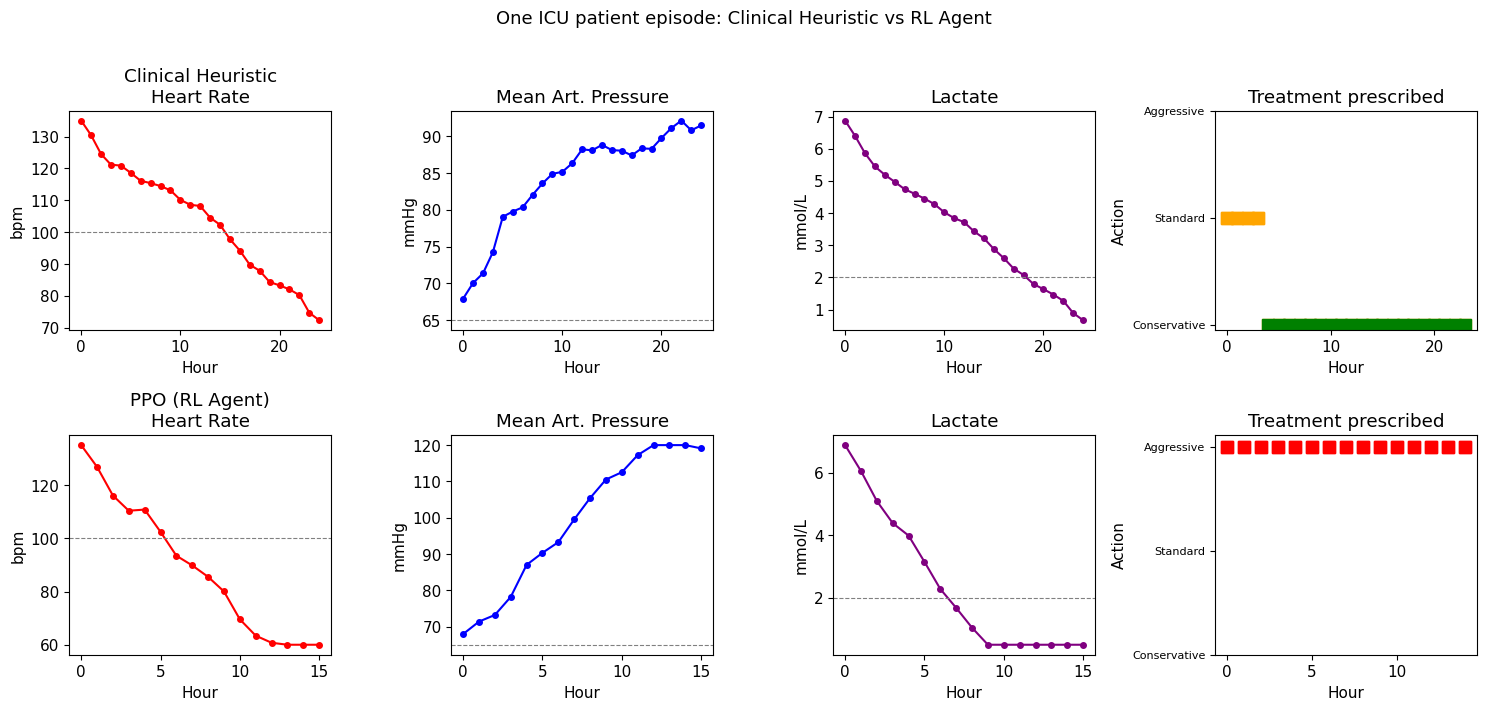

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
# ---- Visualise one episode: what treatment did the RL agent prescribe? ----

def trace_episode(policy_fn, seed=7):
    env = SepsisEnv()
    obs, _ = env.reset(seed=seed)
    hrs, maps, lacs, sofas, actions = \
        [env.hr], [env.map_], [env.lac], [env.sofa], []

    for _ in range(24):
        action = policy_fn(obs)
        obs, _, terminated, truncated, info = env.step(action)
        hrs.append(info['hr']); maps.append(info['map'])
        lacs.append(info['lactate']); sofas.append(info['sofa'])
        actions.append(action)
        if terminated or truncated:
            break
    return hrs, maps, lacs, sofas, actions

hrs_h, maps_h, lacs_h, sofas_h, acts_h = trace_episode(clinical_heuristic, seed=7)
hrs_r, maps_r, lacs_r, sofas_r, acts_r = trace_episode(sb3_policy,          seed=7)

action_labels = {0: 'Conservative', 1: 'Standard', 2: 'Aggressive'}
action_colors = {0: 'green', 1: 'orange', 2: 'red'}

fig, axes = plt.subplots(2, 4, figsize=(15, 7))

for row, (label, hrs, maps, lacs, sofas, acts) in enumerate([
    ('Clinical Heuristic', hrs_h, maps_h, lacs_h, sofas_h, acts_h),
    ('PPO (RL Agent)',     hrs_r, maps_r, lacs_r, sofas_r, acts_r),
]):
    T = len(hrs)
    t = range(T)

    axes[row, 0].plot(t, hrs, 'r-o', markersize=4)
    axes[row, 0].axhline(100, color='gray', linestyle='--', linewidth=0.8, label='normal <100')
    axes[row, 0].set_title(f'{label}\nHeart Rate'); axes[row, 0].set_ylabel('bpm')

    axes[row, 1].plot(t, maps, 'b-o', markersize=4)
    axes[row, 1].axhline(65, color='gray', linestyle='--', linewidth=0.8, label='target >65')
    axes[row, 1].set_title('Mean Art. Pressure'); axes[row, 1].set_ylabel('mmHg')

    axes[row, 2].plot(t, lacs, 'purple', marker='o', markersize=4)
    axes[row, 2].axhline(2.0, color='gray', linestyle='--', linewidth=0.8, label='target <2')
    axes[row, 2].set_title('Lactate'); axes[row, 2].set_ylabel('mmol/L')

    axes[row, 3].plot(t[:-1], acts, 's', markersize=8,
                      color=[action_colors[a] for a in acts][0])
    for i, a in enumerate(acts):
        axes[row, 3].plot(i, a, 's', color=action_colors[a], markersize=8)
    axes[row, 3].set_yticks([0, 1, 2])
    axes[row, 3].set_yticklabels(['Conservative', 'Standard', 'Aggressive'], fontsize=8)
    axes[row, 3].set_title('Treatment prescribed'); axes[row, 3].set_ylabel('Action')

    for ax in axes[row]: ax.set_xlabel('Hour')

plt.suptitle('One ICU patient episode: Clinical Heuristic vs RL Agent', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sepsis_episode.png', dpi=100); plt.show()

/tmp/ipykernel_10148/999367803.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('RdYlGn_r', 3), vmin=-0.5, vmax=2.5)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


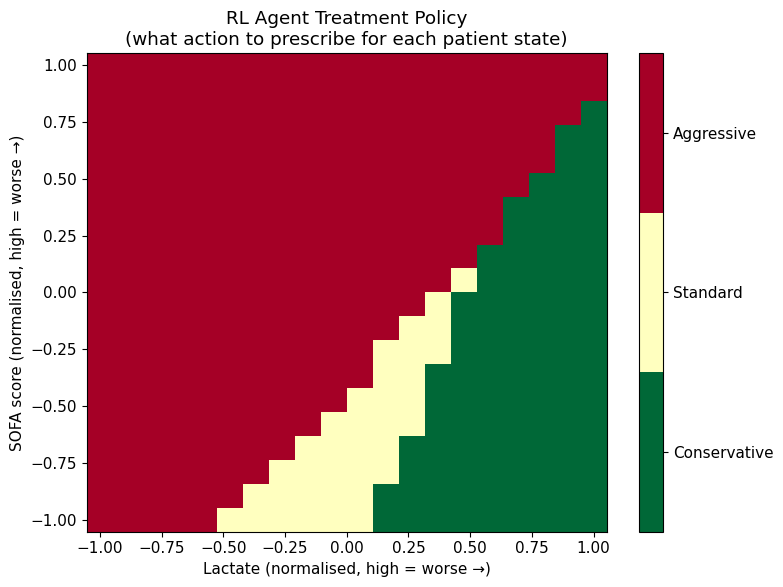

Green = conservative, Yellow = standard, Red = aggressive treatment
The agent should learn to be more aggressive for sicker patients (top-right).


In [26]:
# ---- What has the RL agent learned? Visualise treatment policy ----
# Plot: for each (SOFA level, lactate level), what action does the RL agent choose?

sofa_vals = np.linspace(-1, 1, 20)   # normalised SOFA
lac_vals  = np.linspace(-1, 1, 20)   # normalised lactate
policy_map = np.zeros((len(sofa_vals), len(lac_vals)))

for i, sofa_n in enumerate(sofa_vals):
    for j, lac_n in enumerate(lac_vals):
        # Fix HR and MAP at mid-range (moderate)
        obs = np.array([0.0, 0.0, lac_n, sofa_n], dtype=np.float32)
        policy_map[i, j] = sb3_policy(obs)

plt.figure(figsize=(8, 6))
im = plt.pcolormesh(lac_vals, sofa_vals, policy_map,
                    cmap=plt.cm.get_cmap('RdYlGn_r', 3), vmin=-0.5, vmax=2.5)
cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.set_ticklabels(['Conservative', 'Standard', 'Aggressive'])
plt.xlabel('Lactate (normalised, high = worse →)')
plt.ylabel('SOFA score (normalised, high = worse →)')
plt.title('RL Agent Treatment Policy\n(what action to prescribe for each patient state)')
plt.tight_layout()
plt.savefig('rl_policy_map.png', dpi=100); plt.show()
print('Green = conservative, Yellow = standard, Red = aggressive treatment')
print('The agent should learn to be more aggressive for sicker patients (top-right).')

---
## Summary

| Algorithm | Key idea | Convergence | Pros / Cons |
|---|---|---|---|
| **REINFORCE** | Log-derivative trick; scale log-prob by return | Slow, high variance | Simple; unstable |
| **Actor-Critic** | Add a value critic as baseline; advantage = $A_t = G_t - V(s_t)$ | Faster, lower variance | Two networks to tune |
| **PPO** | Clip policy ratio to prevent large policy changes; reuse data $K$ epochs | Much faster, stable | Industry standard |

### Key equations

| Name | Formula |
|---|---|
| Discounted return | $G_t = \sum_{t'=t}^T \gamma^{t'-t} r_{t'}$ |
| Bellman equation | $V^\pi(s) = \mathbb{E}[r + \gamma V^\pi(s')]$ |
| TD error | $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ |
| Policy gradient | $\nabla_\theta J = \mathbb{E}[\nabla_\theta \log\pi_\theta(a|s) \cdot A_t]$ |
| PPO clip loss | $\mathcal{L} = \mathbb{E}[\min(r_t A_t,\; \text{clip}(r_t, 1\pm\varepsilon) A_t)]$ |

### Biomedical take-aways

- **Dynamic Treatment Regimes** are a natural MDP — every patient visit is a state, treatment choice is an action, and long-term health outcome is the reward.
- RL can discover **individualised, adaptive policies** that outperform fixed protocols by exploiting patient-specific state information.
- Key challenges in clinical RL: **off-policy learning** (we can't experiment freely on patients), **reward shaping** (proxy rewards from EHRs), and **distributional shift** at deployment.
- Landmark work: Komorowski et al. *Nature Medicine* 2018 (sepsis); Raghu et al. 2017; Liu et al. *Nature Medicine* 2020 (depression treatment).

---
## Exercises

1. **Discount factor**: In `train_reinforce`, change $\gamma$ from 0.99 to 0.9 and 0.5. How does this affect learning? What does a small $\gamma$ "tell" the agent?

2. **Entropy bonus**: In the Actor-Critic training, increase `entropy_coef` from 0.01 to 0.1. Does the agent explore more? Does it eventually converge to a better policy?

3. **Clip $\varepsilon$**: In `PPOAgent`, change `eps_clip` from 0.2 to 0.05 (very conservative) and 0.5 (very permissive). How does this change learning stability?

4. **Reward shaping**: In `SepsisEnv`, add a bonus for keeping MAP > 65 and HR < 100 at every step. Does the RL agent recover faster?

5. **Harder patient**: In `SepsisEnv.reset()`, change the initial SOFA range to `(15, 22)`. Retrain PPO. How much harder is the task?

6. **Real data framing**: Read Komorowski et al. *Nature Medicine* 2018. What are the 5 state features they use? How do they handle the fact that they cannot do online RL on real patients?